We will represent our line using the vector , and our points as . Note that the points are 2D data! They have three coordinates to account for the constant in the equation of the line. (this also ensures that the line goes through the origin, but we'll get to that later)

If a point is misclassified, update  as  or  depending on the class of 

Create a dataset of two classes that is linearly separable
Generate a random line (you may need to manually intervene so that it is in the right range)
Plot the line and the data
For each class, find two misclassified points, update  and plot the line and the data

In [68]:
#Generate values belonging to 2 classes m and f

import numpy as np

np.random.seed(42)

n = 4

fw = np.random.uniform(1, 4, n)
fh = np.random.uniform(6, 8, n)

mw = np.random.uniform(4, 7, n)
mh = np.random.uniform(8, 11, n)

In [69]:
print(fw)
print(fh)
print(mw)
print(mh)

[2.12362036 3.85214292 3.19598183 2.79597545]
[6.31203728 6.31198904 6.11616722 7.73235229]
[5.80334504 6.12421773 4.06175348 6.90972956]
[10.49732792  8.63701733  8.5454749   8.55021353]


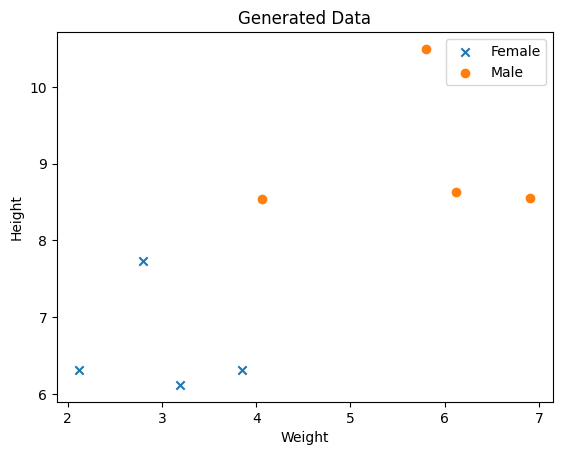

In [70]:
import matplotlib.pyplot as plt

plt.scatter(fw, fh, label="Female", marker = 'x')
plt.scatter(mw, mh, label="Male", marker = 'o')

plt.xlabel("Weight")
plt.ylabel("Height")
plt.legend()
plt.title("Generated Data")
plt.show()


In [73]:
#Generate a random line - (x2 - w0 - w1x1 = 0)

w0 = 15
w1 = -3


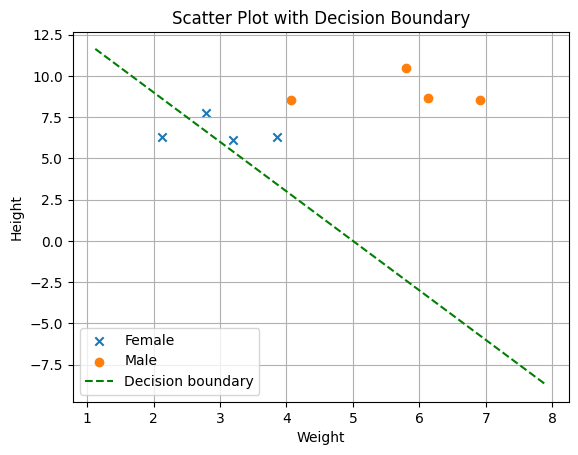

In [74]:
# Plot female data (fw, fh)
plt.scatter(fw, fh, label="Female", marker='x')

# Plot male data (mw, mh)
plt.scatter(mw, mh, label="Male", marker='o')

# Create x values for line
x_vals = np.linspace(min(fw.min(), mw.min()) - 1,
                     max(fw.max(), mw.max()) + 1, 100)

# Compute y values from line equation
y_vals = w0 + (w1 * x_vals)

# Plot the line
plt.plot(x_vals, y_vals, linestyle="--", label="Decision boundary", color = 'green')

# Labels
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Scatter Plot with Decision Boundary")

plt.legend()
plt.grid(True)
plt.show()


In [84]:
# Labels:  1 = male, -1 = female
y_true = np.concatenate((np.ones(n) * -1, np.ones(n)))

In [110]:
# Combine data
x1 = np.concatenate((fw, mw))  # weight
x2 = np.concatenate((fh, mh))  # height

In [111]:
def classify_fm(x1,x2,w0,w1):
   #Compute scores for points with respect to line 

    score = x2 - w0 - (w1*x1)
    
    y_pred= []
    for i in score:
        if i > 0:
            y_pred.append(1)
        else: 
            y_pred.append(-1)
        
    
    y_pred = np.array(y_pred)
    
    

    return y_pred

In [113]:
y_pred = classify_fm(x1,x2,w0,w1)

In [125]:
misclassified = (y_true * y_pred) < 0


In [126]:
print(misclassified)

[False  True  True  True False False False False]


In [127]:
misclassified_x1 = x1[misclassified]
misclassified_x2 = x2[misclassified]

print(misclassified_x1)
print(misclassified_x2)

[3.85214292 3.19598183 2.79597545]
[6.31198904 6.11616722 7.73235229]


In [130]:
# Line represented as a vector
w_old = np.array([-w0, -w1, 1])

# Pick the first misclassified point
x1_mis = misclassified_x1[0]
x2_mis = misclassified_x2[0]

misclassified_labels = y_true[misclassified]
y_mis = misclassified_labels[0]

# Misclassified point as a vector
x_mis = np.array([1, x1_mis, x2_mis])

# Update line vector
w_new = w_old + (y_mis * x_mis)

print("Original line vector:", w_old)
print("Misclassified point vector:", x_mis)
print("True label:", y_mis)
print("Updated line vector:", w_new)

Original line vector: [-15   3   1]
Misclassified point vector: [1.         3.85214292 6.31198904]
True label: -1.0
Updated line vector: [-16.          -0.85214292  -5.31198904]


In [144]:
import numpy as np
import matplotlib.pyplot as plt

def plot_classification(x1, x2, y_true, w, title="Classification Plot"):
    """
    Female = x
    Male = o

    Correctly classified:
        Female = blue x
        Male = orange o

    Misclassified:
        Red x or red o, depending on true class

    w = [a, b, c] represents:
        a + b*x1 + c*x2 = 0
    """

    # Create point vectors: [1, x1, x2]
    X = np.column_stack((np.ones(len(x1)), x1, x2))

    # Predict labels
    scores = np.dot(X, w)
    y_pred = np.where(scores >= 0, 1, -1)

    # Classification masks
    correct_mask = (y_true * y_pred) > 0
    misclassified_mask = (y_true * y_pred) < 0

    # Class masks
    female_mask = y_true == -1
    male_mask = y_true == 1

    # Correctly classified females
    plt.scatter(
        x1[female_mask & correct_mask],
        x2[female_mask & correct_mask],
        color="blue",
        marker="x",
        label="Female - Correct"
    )

    # Correctly classified males
    plt.scatter(
        x1[male_mask & correct_mask],
        x2[male_mask & correct_mask],
        color="orange",
        marker="o",
        label="Male - Correct"
    )

    # Misclassified females
    plt.scatter(
        x1[female_mask & misclassified_mask],
        x2[female_mask & misclassified_mask],
        color="red",
        marker="x",
        s=80,
        label="Female - Misclassified"
    )

    # Misclassified males
    plt.scatter(
        x1[male_mask & misclassified_mask],
        x2[male_mask & misclassified_mask],
        color="red",
        marker="o",
        s=80,
        label="Male - Misclassified"
    )

    # Plot decision boundary
    a, b, c = w
    x_vals = np.linspace(x1.min() - 1, x1.max() + 1, 100)

    if c != 0:
        y_vals = -(a + b * x_vals) / c
        plt.plot(
            x_vals,
            y_vals,
            linestyle="--",
            color="green",
            label="Decision Boundary"
        )

    plt.xlabel("Weight")
    plt.ylabel("Height")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Correctly classified:", np.sum(correct_mask))
    print("Misclassified:", np.sum(misclassified_mask))

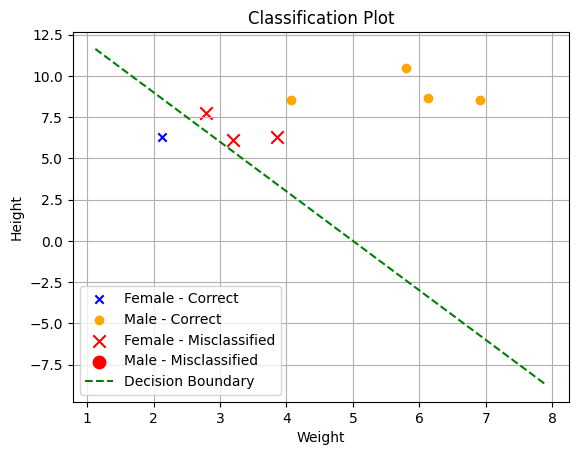

Correctly classified: 5
Misclassified: 3


In [145]:
plot_classification(x1, x2, y_true, w_old, title="Classification Plot")

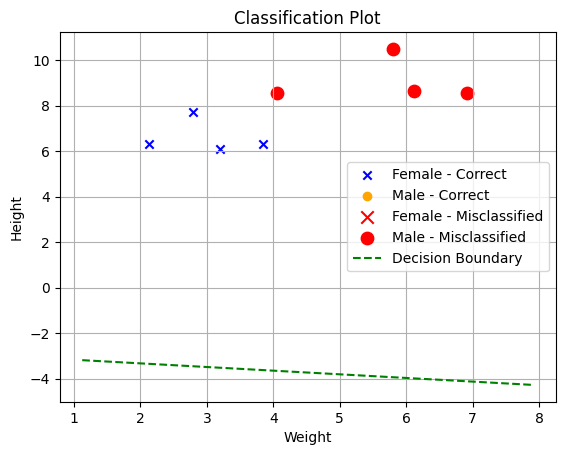

Correctly classified: 4
Misclassified: 4


In [146]:
plot_classification(x1, x2, y_true, w_new, title="Classification Plot")

In [147]:
def count_misclassified(x1, x2, y_true, w):
    
    X = np.column_stack((np.ones(len(x1)), x1, x2))
    scores = np.dot(X, w)
    
    y_pred = []
    
    for i in range(len(scores)):
        if scores[i] < 0:
            y_pred.append(-1)
        else:
            y_pred.append(1)

    y_pred = np.array(y_pred)
    
    misclassified = (y_true * y_pred) < 0
    count_mis = np.sum(misclassified)

    return count_mis

In [148]:
count_misclassified(x1, x2, y_true, w_old)

np.int64(3)